# 04. Exploratory Data Analysis (EDA): Market Dynamics
**Cut-off Date: 2026-05-26**

This notebook serves as the final deep dive into the master dataset. We aim to uncover actionable insights—specifically looking for price elasticity, demand patterns, and structural validation of our feature engineering assumptions (e.g., carrier type classification).

## Objectives
- Market Characterization: Profile the dataset to reveal underlying price behaviors across different routes (Short-Haul vs. Long-Haul) and time horizons.
- Assumption Validation: Quantify the impact of our Carrier Type labeling logic. By comparing the price distributions of Full Service Carrier and Low Cost Carrier, we validate that our classification correctly captures the distinct pricing strategies in the data.
- Insight Discovery: Identify latent patterns—such as weekend premiums or holiday surges—that will inform our Random Forest modeling strategy.
- Quality Assurance: Flag any anomalies or outliers (e.g., extreme fare dispersion) that may need to be handled before training begins.


### Environment Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime

In [2]:
df = pd.read_csv('dataset - base (2026-05-26).csv')

#### Carrier-Specific Filtering
To maintain the integrity of the price trend analysis, a strategic filter was applied to standardise the comparison of fares across different carrier business models.
- For all routes except LHR, Low-Cost Carrier (LCC) data was isolated. The manual dataset (notebook 0) was specifically curated to capture the "lowest price available" in the market, and as such, all manual data points were assumed to be LCC fares. This provides a clean "price floor" benchmark, preventing the significant price premiums of Full-Service Carriers (FSC) from introducing excessive variance (noise) into the analysis.
- The SIN-LHR route was explicitly exempted from this LCC filter. As this route is serviced exclusively by Full-Service Carriers, removing them would result in a total loss of data coverage. By retaining FSC data for LHR while filtering it for other routes, this ensures the analysis applies consistent price signals unique to each market's operational reality.

In [3]:
is_lcc_carrier = df['is_lcc'] == 1
is_lhr_route = df['other_airport'] == "LHR"

### Booking Window Analysis: Price Intensity and Days to Departure

*Carrier-Specific Filtering Applied*

C:\Users\user\AppData\Local\Temp\ipykernel_11180\3489654716.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = master_df.pivot_table(index='route',


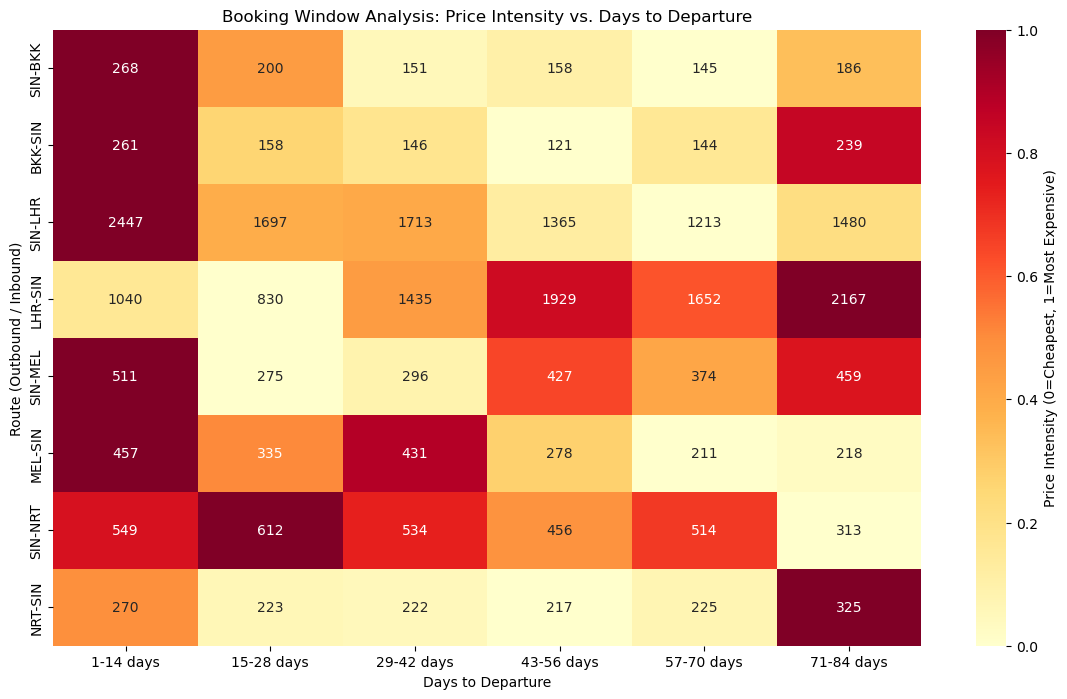

In [4]:
# Sorting routes by airport and ensuring SIN is the first row.
master_df = df[is_lcc_carrier | is_lhr_route].sort_values(by=['other_airport','out_inbound'])
ordered_routes = master_df['route'].unique() 

# Days to deapture bins - define time-based bins dynamically for consistent chronological ordering across heatmap visualisation. 
bin_size = 14 
max_days = master_df['days_to_departure'].max()
bins = np.arange(0, max_days + bin_size, bin_size)
labels = [f"{int(bins[idx])+1}-{int(bins[idx+1])} days" for idx in range(len(bins)-1)]

in_memory_windows = pd.cut(
    master_df['days_to_departure'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

# Pivot data for the heatmap
pivot = master_df.pivot_table(index='route',
                              columns=in_memory_windows,
                              values='price', 
                              aggfunc='mean')

# Reorder columns to sort by route and day
pivot = pivot.reindex(index=ordered_routes)

# Apply row-level normalisation to see price intensity by route
pivot_norm = pivot.apply(lambda y: (y - y.min()) / (y.max() - y.min()), axis=1)

# Plot the Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    data=pivot_norm,     # Use normalized data for the colour
    annot=pivot,          # Use average prices for the TEXT labels
    fmt=".0f",            # Format the numbers (0 decimal places)
    cmap="YlOrRd",        # "Yellow-Green-Blue" color map
    cbar_kws={'label': 'Price Intensity (0=Cheapest, 1=Most Expensive)'}
)

plt.title("Booking Window Analysis: Price Intensity vs. Days to Departure")
plt.xlabel("Days to Departure")
plt.ylabel("Route (Outbound / Inbound)")
plt.show()

#### Analysis
##### Last Minute Price Escalation
Consistent with initial exploratory observations, a robust positive correlation persists between proximity to departure and airfare cost. Across all analyzed sectors, ticket prices tend to reach peak intensity during the final 1-14 days to departure. Dynamic pricing algorithms systematically close out promotional yield buckets within this 2-week window to extract maximum consumer surplus from inelastic, last-minute business or emergency travelers.

##### Directional Asymmetry
- Short haul (SIN-BKK vv)
  - Both outbound and inbound flight prices were similar, where cells were in yellow to orange from 15 to 70 days to departure. Hence, for these flights operated by LCCs, there is minimal directional asymmetry in airfare prices.
- Long haul (SIN-MEL vv and SIN-LHR vv)
  - When observing these directional pairs within identical booking horizons, the heatmap reveals a clear flip in color states: while one directional leg registers deep visual intensity (dark/deep surge colors), its reciprocal leg sits at a relaxed, light yellowish pricing baseline.
  - If the machine learning model did not account for direction, this could hit a performance roadblock, where these price waves would smooth each other out into a generic average line. 

##### Comparison Against Manual Dataset
While the manual dataset suggested a smooth, continuous linear decline as the advance purchase horizon expanded, the master dataset displays some volatility. This could be due to the manual dataset employing data smoothing and time-averaged aggregations. On the other hand, the API dataset captures unfiltered, instantaneous spot fare snapshots.

### Price Distribution: Price by Route

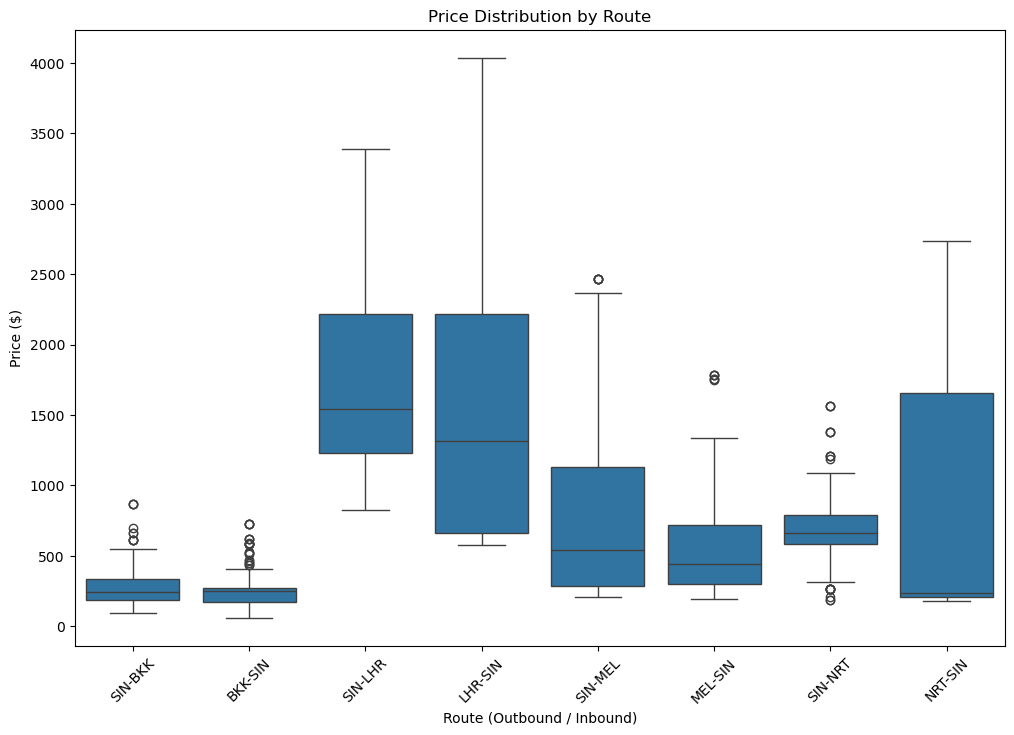

In [5]:
plt.figure(figsize=(12, 8))

# Sorting routes by airport and ensuring SIN is the first row.
sns.boxplot(data=df.sort_values(by=['other_airport','out_inbound']), x='route', y='price')

plt.xticks(rotation=45)
plt.title("Price Distribution" Price by Route")
plt.xlabel("Route (Outbound / Inbound)")
plt.ylabel("Price ($)")
plt.show()

#### Analysis
##### SIN-BKK vv
Similar to the analysis done in the manual dataset, mean fares for both legs are closely aligned. This suggests a stable, high frequency market where price competition is intense. 

### Price Distribution: Price by Route (LCC)

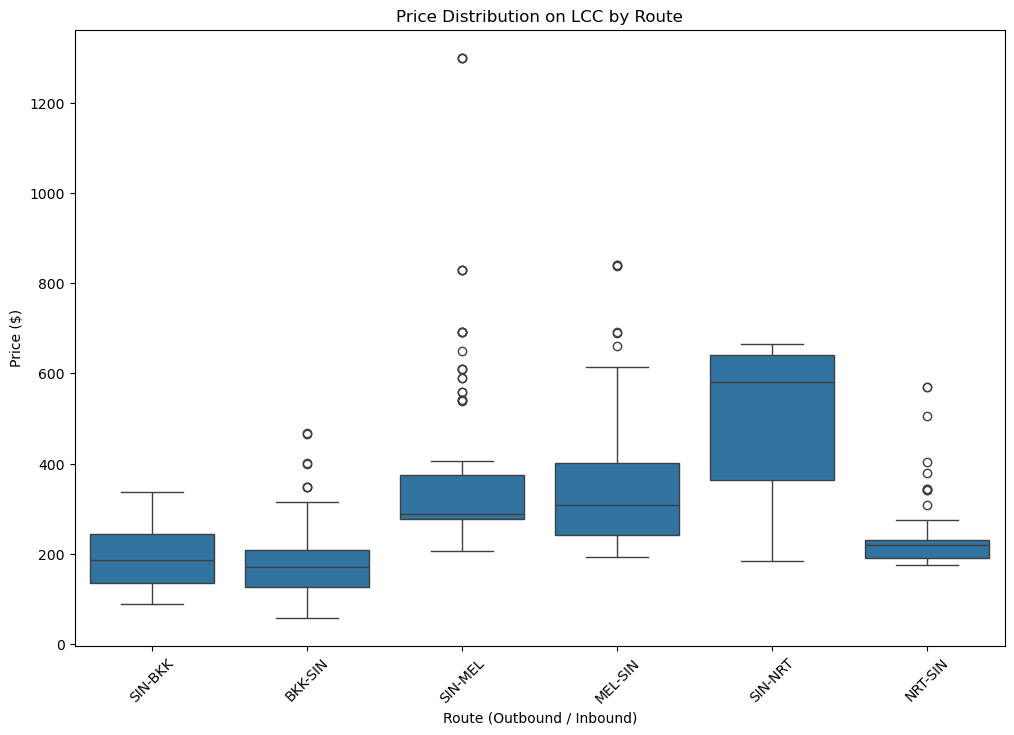

In [6]:
plt.figure(figsize=(12, 8))

# Sorting routes by airport and ensuring SIN is the first row.
sns.boxplot(data=df[is_lcc_carrier==1].sort_values(by=['other_airport','out_inbound']), x='route', y='price')

plt.xticks(rotation=45)
plt.title("Price Distribution: Price by Route (LCC)")
plt.xlabel("Route (Outbound / Inbound)")
plt.ylabel("Price ($)")
plt.show()

#### Analysis
##### SIN-MEL vv
Like the analysis performed for the manual dataset, the inbound MEL-SIN leg exhibits a higher upper whisker compared to its outbound leg. The inbound leg's whisker extends significantly higher indicates that while both routes share relatively similar price floors, the inbound leg operates at a much more aggresive and volatile fare ceiling.  

##### SIN-NRT vv
The median price for flights departing Singapore (SIN-NRT) scales dramatically higher than the return leg. This gap confirms a robust, sustained volume of high-fare bookings than a distribution skewed by isolated spikes. The minimum whiskers sits almost identical price thresholds for both sectors. This suggests that while both legs have similar absolute floor price to breakeven, the velocity at which seats escape this floor differs by direction. The outbound leg (SIN-NRT) shows a distribution with few outliers. In contract, the inbound leg shows a tightly compressed low-fare box but leaves a long, volatile trail of positive extreme outliers.


### Price Distribution: Price by Route (FSC)

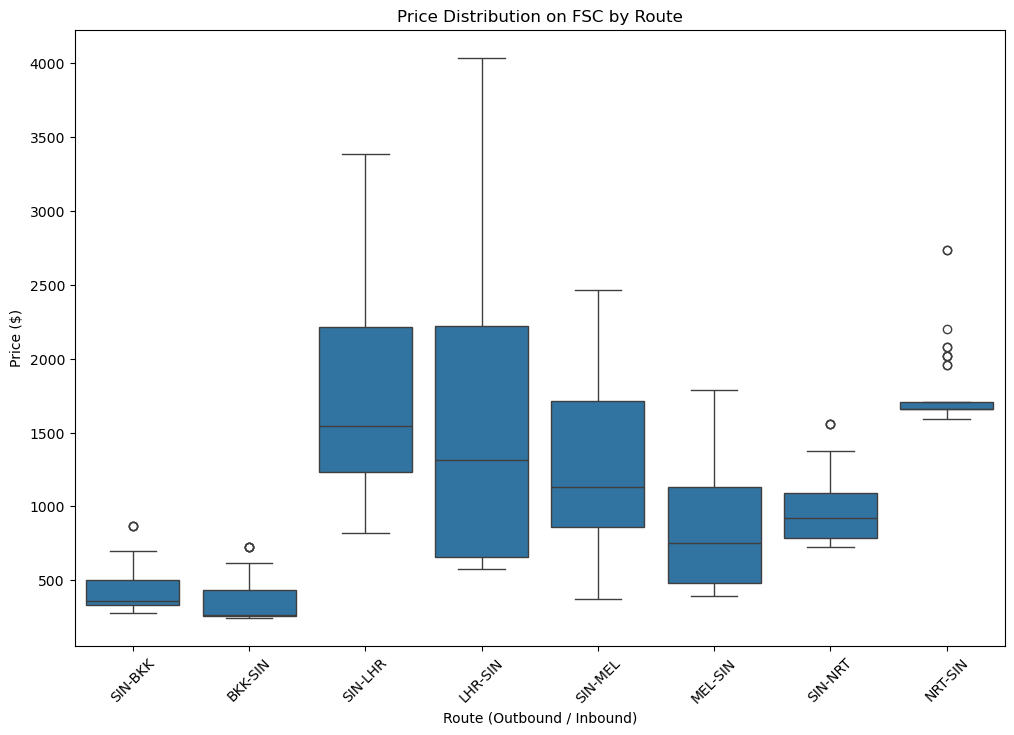

In [7]:
plt.figure(figsize=(12, 8))

# Sorting routes by airport and ensuring SIN is the first row.
sns.boxplot(data=df[is_lcc_carrier==0].sort_values(by=['other_airport','out_inbound']), x='route', y='price')

plt.xticks(rotation=45)
plt.title("Price Distribution: Price by Route (FSC)")
plt.xlabel("Route (Outbound / Inbound)")
plt.ylabel("Price ($)")
plt.show()

#### Analysis
##### SIN-LHR vv
SIN-LHR vv show considerable upward stretch and high volatility. Notably, LHR-SIN exhibits a massive distance between its upper quartile and maximum whisker boundary. This shows support for geopolitical risk premiums from the Middle East conflict. 

- Middle East airspace detour

Due to the active conflicts, carriers divert to lengthened paths to reach LHR. This adds additional costs such as fuel, crew allowances, and shortens turnaround efficiency.
- Inventory constraints

Sudden operational cost surges or rapid booking constraints cause ticket prices to skyrocket.

##### SIN-MEL vv
The outbound SIN-MEL sector shows a positive price spike as the interquartle range box sits higher than its inbound MEL-SIN sector. This could be due to the geopolitical spillover traffic from the Middle East conflict, where due to the contraction in capacity from the Middle Eastern hubs, waves of passengers are rerouted. Singapore being the primary alternative hub for East-West transit, it has borne the brunt of this passenger displacement. With the sudden influx of emergency bookings filling in available seats on the Singapore-Australia legs, it causes supply collapses that force dynamic booking algorithms to trigger premium fare buckets.

This pricing trend was absent on Low-Cost Carriers—yielding a uniform distribution—because LCCs operate on isolated point-to-point systems that lack the interline booking frameworks, alliance partnerships, and legacy passenger protection protocols integrated into full-service carrier networks. 

### Price Distribution: Label Setup

In [8]:
# Label Re-mapping
def map_binary_labels(series, active_label, inactive_label):
    type_safe_dict = {
        True: active_label, False: inactive_label,
        1: active_label,    0: inactive_label,
        'True': active_label, 'False': inactive_label,
        '1': active_label,    '0': inactive_label,
        1.0: active_label,  0.0: inactive_label
    }
    return series.map(type_safe_dict)

# Mapping holiday columns to is and not holidays 
df['sin_ph_label'] = map_binary_labels(df['is_holiday_sin'], 'Singapore PH', 'Not Singapore PH')
df['dest_ph_label'] = map_binary_labels(df['is_holiday_other'], 'Destination PH', 'Not Destination PH')
df['sch_holiday_label'] = map_binary_labels(df['is_sch_holiday'], 'School Holiday Term', 'Standard Term')

### Price Distribution: Singapore Public Holiday

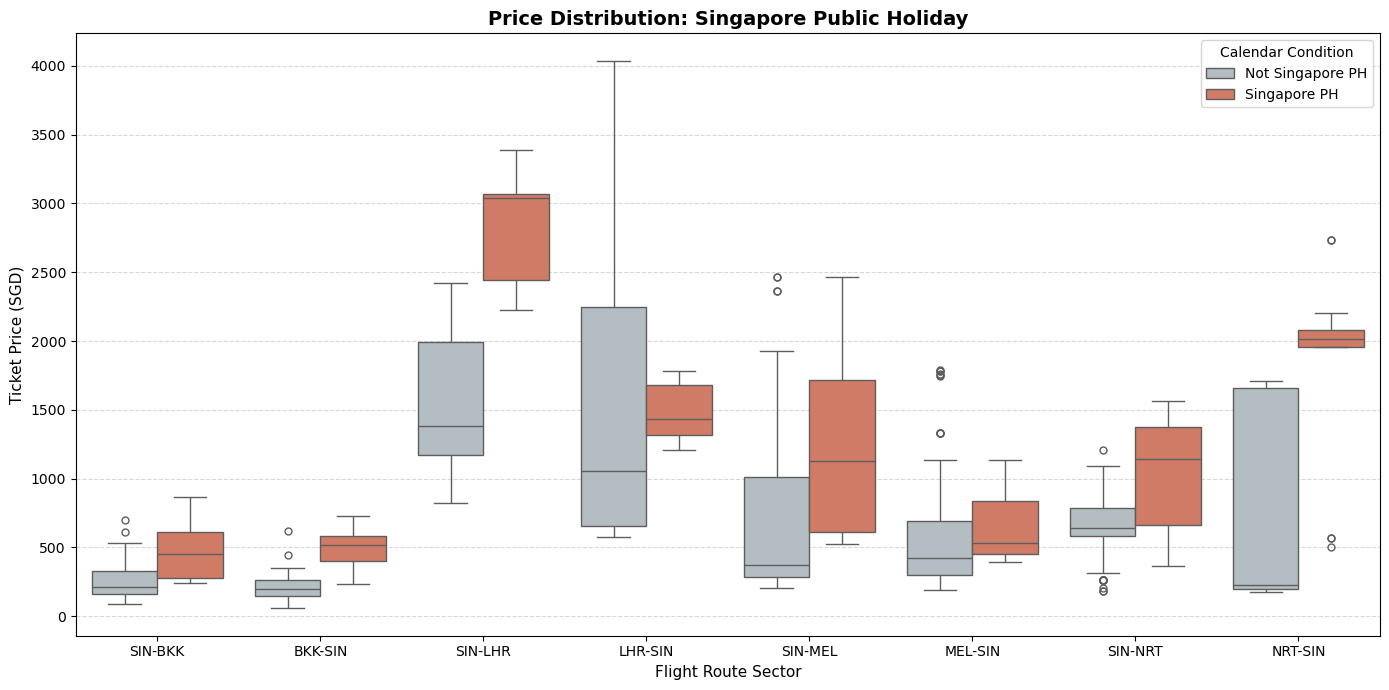

In [9]:
# Singapore PH

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df,
    x='route',
    y='price',
    hue='sin_ph_label',
    order=ordered_routes,
    hue_order=['Not Singapore PH', 'Singapore PH'],
    palette=['#b2bec3', '#e17055'], # Gray baseline vs vibrant demand surge coral
    fliersize=5
)
plt.title("Price Distribution: Singapore Public Holiday", fontsize=14, weight='bold')
plt.xlabel("Flight Route Sector", fontsize=11)
plt.ylabel("Ticket Price (SGD)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Calendar Condition")
plt.tight_layout()
plt.show()

#### Analysis
##### SIN-BKK vv
For the regional getaway, the median price more than doubles during a Singapore PH. The lower whisker of the holiday box sits higher than the median of the standard box. This shows that airlines do not just raise prices, they pull all cheap inventory off the market completely.

##### Outbound Premium
- SIN-LHR
The moment the Singapore PH triggers, the entire IQR box shifts up, with no overlap between the core boxes. This shows that holiday constraints create a high premium price floor.
- SIN-MEL and SIN-NRT
For both of these routes, the holiday box expands significantly. The median jumps and the upper portions of the boxes scale higher, showing that leisure travelers departign from Singapore are highly price inelastic. 

### Price Distribution: Destination Public Holiday

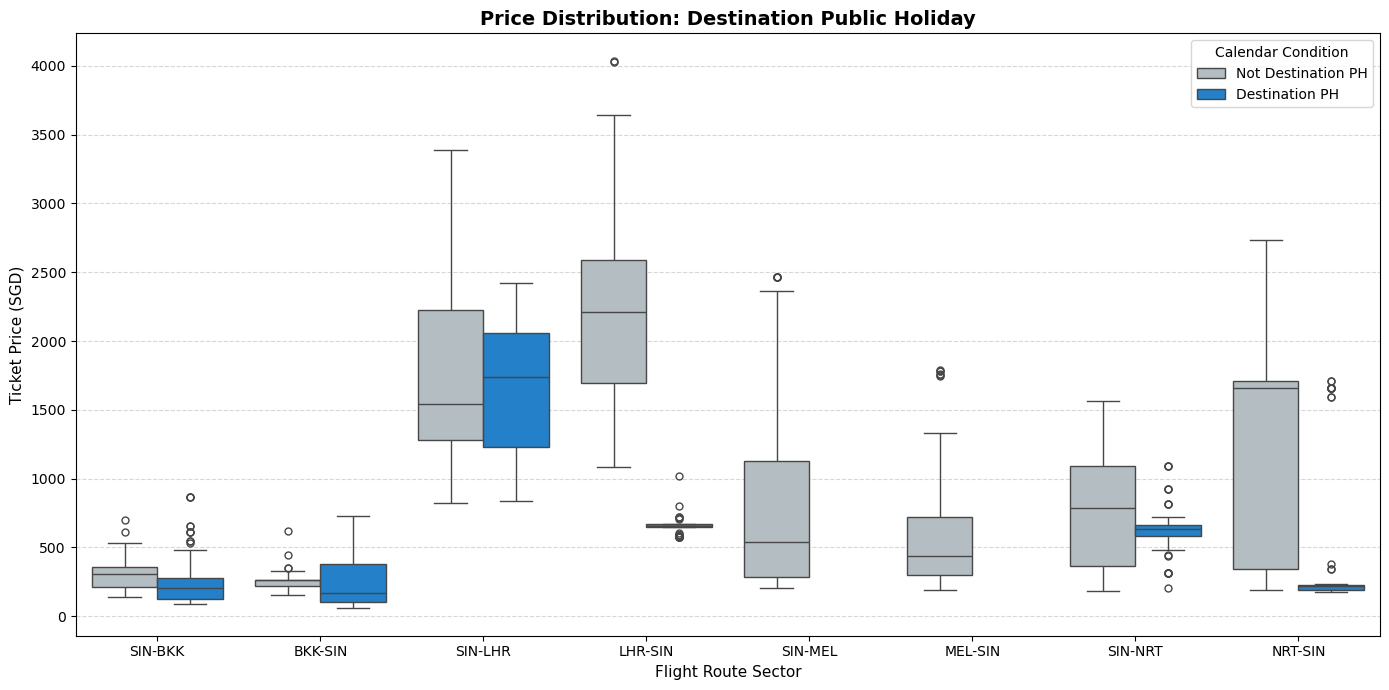

In [10]:
# Destination PH

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df,
    x='route',
    y='price',
    hue='dest_ph_label',
    order=ordered_routes,
    hue_order=['Not Destination PH', 'Destination PH'],
    palette=['#b2bec3', '#0984e3'], # Gray baseline vs vibrant demand surge coral
    fliersize=5
)
plt.title("Price Distribution: Destination Public Holiday", fontsize=14, weight='bold')
plt.xlabel("Flight Route Sector", fontsize=11)
plt.ylabel("Ticket Price (SGD)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Calendar Condition")
plt.tight_layout()
plt.show()

*Note: There are no national public holidays in Australia between May and Dec 2026.*

### Price Distribution: School Holiday

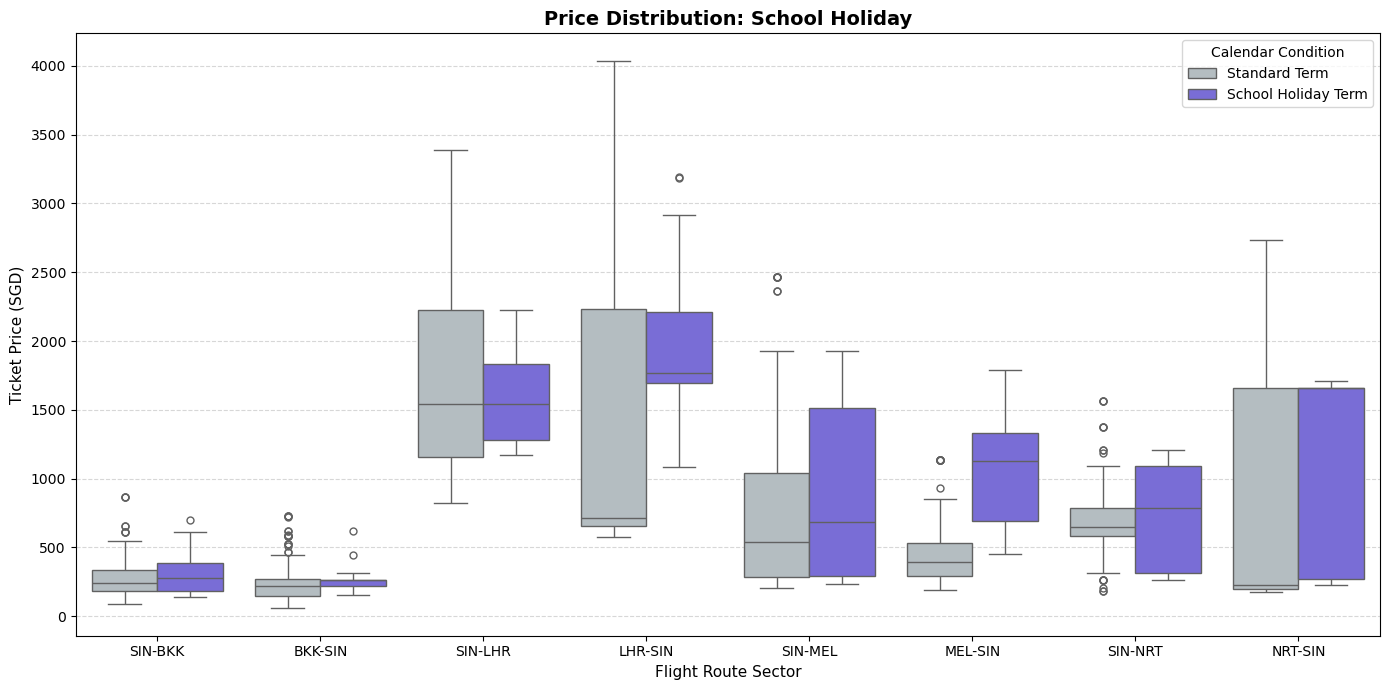

In [11]:
# School Holiday

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df,
    x='route',
    y='price',
    hue='sch_holiday_label',
    order=ordered_routes,
    hue_order=['Standard Term','School Holiday Term'],
    palette=['#b2bec3', '#6c5ce7'], # Gray baseline vs vibrant demand surge coral
    fliersize=5
)
plt.title("Price Distribution: School Holiday", fontsize=14, weight='bold')
plt.xlabel("Flight Route Sector", fontsize=11)
plt.ylabel("Ticket Price (SGD)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Calendar Condition")
plt.tight_layout()
plt.show()

#### Analysis
##### SIN-BKK vv
There is minimal difference in the upper quartile of the interquartile range. This is reflective of the competitve market for regional routes, where airfare prices converge.

##### LHR-SIN and MEL-SIN
The interquartile range of the school holiday term sit on the upper end or surpass the school term interquartle range. This suggests the higher demand from international students returning home for the holidays. 